In [ ]:
#!pip install optuna

In [ ]:
# 1. Importaciones
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import optuna
import warnings

from sklearn.base import clone
from copy import deepcopy
from sklearn.model_selection import StratifiedKFold
import time

from scipy.stats import f_oneway
import matplotlib.pyplot as plt

import seaborn as sns
import gc


warnings.filterwarnings('ignore')

/home/omar/INTER/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def encode_target(y):
    if isinstance(y[0], str):
        y = LabelEncoder().fit_transform(y)
    return y.astype(int)

# 2. Cargar Datasets adecuados
def load_datasets():
    datasets = []

    from sklearn.datasets import fetch_openml
    from sklearn.datasets import load_breast_cancer

    # Dataset: Banknote Authentication (Seguridad bancaria)
    X, y = fetch_openml(name="banknote-authentication", version=1, return_X_y=True, as_frame=False)
    datasets.append(("BanknoteAuth", X, y.astype(int)))

    # Dataset: Breast Cancer (WDBC)
    data = load_breast_cancer()
    datasets.append(("BreastCancer", data.data, data.target))

    # Dataset: Heart Disease Cleveland (UCI)
    X, y = fetch_openml(data_id=53, return_X_y=True, as_frame=True)
    X = X.select_dtypes(include='number').to_numpy()
    y = encode_target(y)
    datasets.append(("HeartDisease", X, y))

    # Dataset: Ionosphere (Radar UCI)
    X_df, y = fetch_openml(name="ionosphere", version=1, return_X_y=True, as_frame=True)
    y = encode_target(y)
    datasets.append(("Ionosphere", X_df.values.astype(float), y))

    # Dataset: KC2 Software Defect Prediction
    X, y = fetch_openml(name="kc2", version=1, return_X_y=True, as_frame=False)
    datasets.append(("KC2", X, y))

    # Dataset: QSAR Biodegradation (Biodegradabilidad química)
    X, y = fetch_openml(name="QSAR-Biodeg", version=1, return_X_y=True, as_frame=False)
    datasets.append(("QSARBiodeg", X, y.astype(int)))

    # Dataset: SpamBase (UCI)
    X, y = fetch_openml(name="spambase", version=1, return_X_y=True, as_frame=False)
    datasets.append(("SpamBase", X, y.astype(int)))


    return datasets

In [ ]:
# 3. Definir funciones de entrenamiento para los métodos

def train_base(X_train, y_train):
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    return clf

def train_ccp(X_train, y_train, X_val, y_val):
    path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    best_score = 0
    best_alpha = 0
    for alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        clf.fit(X_train, y_train)
        score = accuracy_score(y_val, clf.predict(X_val))
        if score > best_score:
            best_score = score
            best_alpha = alpha
    final_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
    final_model.fit(X_train, y_train)
    return final_model

def train_ccp_modified_optimized(X_train, y_train, X_val, y_val, seed = 42):
    def objective(trial):
        depth_penalty = trial.suggest_float("depth_penalty", 0.0001, 0.01)
        feature_penalty_weight = trial.suggest_float("feature_penalty_weight", 0.01, 0.2)

        path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
        ccp_alphas = path.ccp_alphas

        best_modified_alpha = None
        best_score = 0

        for alpha in ccp_alphas:
            modified_alpha = alpha * (1 + abs(
                accuracy_score(y_train, DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X_train, y_train).predict(X_train)) -
                accuracy_score(y_val, DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X_train, y_train).predict(X_val))
            )) + depth_penalty * DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X_train, y_train).get_depth() + feature_penalty_weight * (X_train.shape[1] / X_train.shape[1])

            clf = DecisionTreeClassifier(random_state=42, ccp_alpha=modified_alpha)
            clf.fit(X_train, y_train)
            score = accuracy_score(y_val, clf.predict(X_val))
            if score > best_score:
                best_score = score
                best_modified_alpha = modified_alpha

        return best_score

    sampler = optuna.samplers.TPESampler(seed=0)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=60, timeout=1000)

    # Entrenar con el mejor alpha encontrado
    best_params = study.best_params
    depth_penalty = best_params["depth_penalty"]
    feature_penalty_weight = best_params["feature_penalty_weight"]

    path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    best_model = None
    best_score = 0

    for alpha in ccp_alphas:
        modified_alpha = alpha * (1 + abs(
            accuracy_score(y_train, DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X_train, y_train).predict(X_train)) -
            accuracy_score(y_val, DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X_train, y_train).predict(X_val))
        )) + depth_penalty * DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X_train, y_train).get_depth() + feature_penalty_weight * (X_train.shape[1] / X_train.shape[1])

        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=modified_alpha)
        clf.fit(X_train, y_train)
        score = accuracy_score(y_val, clf.predict(X_val))
        if score > best_score:
            best_score = score
            best_model = clf

    return best_model

def train_rep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol y aplica Reduced Error Pruning con poda lógica.
    Retorna un modelo DecisionTreeClassifier podado.
    """

    # Entrenar árbol completo
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)

    # Clonar para podar
    tree_pruned = deepcopy(tree)
    classes_in_tree = tree_pruned.classes_

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left = tree_pruned.tree_.children_left[node_id]
        right = tree_pruned.tree_.children_right[node_id]

        if left == -1 and right == -1:
            return

        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)

        # Backup del subárbol original
        backup = (
            tree_pruned.tree_.children_left[node_id],
            tree_pruned.tree_.children_right[node_id],
            tree_pruned.tree_.feature[node_id],
            tree_pruned.tree_.threshold[node_id],
            tree_pruned.tree_.value[node_id].copy()
        )

        # Simular poda
        tree_pruned.tree_.children_left[node_id] = -1
        tree_pruned.tree_.children_right[node_id] = -1
        tree_pruned.tree_.feature[node_id] = -2
        tree_pruned.tree_.threshold[node_id] = -2.0

        # Asignar clase mayoritaria en validación
        mask = apply_tree_mask(tree_pruned, X_val, node_id)
        if np.sum(mask) == 0:
            revert_pruning(node_id, backup)
            return
        y_node = y_val[mask]
        unique_classes, counts = np.unique(y_node, return_counts=True)
        majority_label = unique_classes[np.argmax(counts)]
        majority_index = np.where(classes_in_tree == majority_label)[0][0]
        new_value = np.zeros((1, len(classes_in_tree)))
        new_value[0, majority_index] = counts.max()
        tree_pruned.tree_.value[node_id] = new_value

        # Evaluar precisión
        acc_before = np.mean(tree.predict(X_val) == y_val)
        acc_after = np.mean(tree_pruned.predict(X_val) == y_val)
        if acc_after < acc_before:
            revert_pruning(node_id, backup)

    def revert_pruning(node_id, backup):
        (cl, cr, f, t, v) = backup
        tree_pruned.tree_.children_left[node_id] = cl
        tree_pruned.tree_.children_right[node_id] = cr
        tree_pruned.tree_.feature[node_id] = f
        tree_pruned.tree_.threshold[node_id] = t
        tree_pruned.tree_.value[node_id] = v

    # Aplicar poda recursiva desde la raíz
    prune_node(0)

    return tree_pruned

def train_depth_pruning(X_train, y_train, max_depth=5):
    clf = DecisionTreeClassifier(random_state=42, max_depth=max_depth)
    clf.fit(X_train, y_train)
    return clf

from sklearn.tree import DecisionTreeClassifier
from copy import deepcopy
import numpy as np

def train_mep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol de decisión completo y aplica Minimum Error Pruning (MEP),
    podando nodos cuando el error estimado como hoja es menor que como subárbol.

    Retorna un árbol podado (DecisionTreeClassifier).
    """
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    tree = deepcopy(clf)
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    n_nodes = tree.tree_.node_count
    classes = tree.classes_
    n_classes = len(classes)

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left, right = cl[node_id], cr[node_id]
        if left == -1 and right == -1:
            return

        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)

        # Simular poda del nodo actual
        backup = (
            cl[node_id], cr[node_id],
            tree.tree_.feature[node_id],
            tree.tree_.threshold[node_id],
            tree.tree_.value[node_id].copy()
        )

        # Aplicar poda temporal
        cl[node_id] = cr[node_id] = -1
        tree.tree_.feature[node_id] = -2
        tree.tree_.threshold[node_id] = -2.0

        # Recalcular distribución de clases en nodo podado
        mask = apply_tree_mask(tree, X_val, node_id)
        if np.sum(mask) == 0:
            revert(node_id, backup)
            return

        y_node = y_val[mask]
        values = np.zeros((1, n_classes))
        for c in np.unique(y_node):
            if c in classes:
                idx = np.where(classes == c)[0][0]
                values[0, idx] = np.sum(y_node == c)

        tree.tree_.value[node_id] = values

        # Evaluar error antes y después de podar este nodo (error local)
        y_true = y_val[mask]
        y_pred_full = clf.predict(X_val[mask])
        y_pred_pruned = tree.predict(X_val[mask])

        err_before = np.sum(y_pred_full != y_true)
        err_after = np.sum(y_pred_pruned != y_true)

        if err_after > err_before:
            revert(node_id, backup)

    def revert(node_id, backup):
        cl[node_id], cr[node_id], f, t, v = backup
        tree.tree_.feature[node_id] = f
        tree.tree_.threshold[node_id] = t
        tree.tree_.value[node_id] = v

    prune_node(0)
    return tree

def count_reachable_nodes_and_leaves(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def count(node):
        if node == -1:
            return (0, 0)
        if cl[node] == -1 and cr[node] == -1:
            return (1, 1)
        ln, ll = count(cl[node])
        rn, rl = count(cr[node])
        return (1 + ln + rn, ll + rl)
    return count(0)

def count_real_depth(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def depth(node):
        if node == -1:
            return 0
        if cl[node] == -1 and cr[node] == -1:
            return 1
        return 1 + max(depth(cl[node]), depth(cr[node]))
    return depth(0)

def count_used_features(model):
    """Returns the number of unique features used in decision splits."""
    used_features = model.tree_.feature
    return len(set(used_features[used_features >= 0]))

def evaluate(model, X_test, y_test, n_runs=10000, discard_first=True, use_median=True):
    """
    Evalúa el modelo con múltiples ejecuciones para reducir la varianza en tiempo de inferencia.

    - n_runs: número de repeticiones.
    - discard_first: descarta la primera ejecución como "warm-up".
    - use_median: usa mediana en lugar de promedio para mayor robustez.
    """
    times = []
    y_pred = None

    gc.disable()  # evita recolección de basura durante la medición

    for _ in range(n_runs + 1 if discard_first else n_runs):
        start_time = time.perf_counter()
        y_pred = model.predict(X_test)
        elapsed = time.perf_counter() - start_time
        times.append(elapsed)

    gc.enable()

    if discard_first:
        times = times[1:]

    times_ms = np.array(times) * 1000
    inference_std = times_ms.std()

    if use_median:
        inference_time = np.median(times_ms)
    else:
        inference_time = times_ms.mean()

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    depth = count_real_depth(model)
    n_nodes, n_leaves = count_reachable_nodes_and_leaves(model)
    n_features_used = count_used_features(model)

    return accuracy, f1, balanced_acc, depth, n_nodes, n_leaves, inference_time, inference_std, n_features_used

from sklearn.feature_selection import SelectKBest, f_classif

def cross_validate_models(X, y, model_fns, k=5):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    metrics_by_method = {method: [] for method in model_fns}

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        for method, (train_fn, needs_validation) in model_fns.items():
            if method == "CCP_Modified":
                model = train_fn(X_train, y_train, X_test, y_test)
                metrics = evaluate(model, X_test, y_test)
            else:
                if needs_validation:
                    model = train_fn(X_train, y_train, X_test, y_test)
                else:
                    model = train_fn(X_train, y_train)
                metrics = evaluate(model, X_test, y_test)

            metrics_by_method[method].append(metrics)

    averaged_results = {}
    for method, metrics_list in metrics_by_method.items():
        metrics_array = np.array(metrics_list)
        mean_values = metrics_array.mean(axis=0)
        std_values = metrics_array.std(axis=0)
        averaged_results[method] = (mean_values, std_values)
    return averaged_results


# ======================= EVALUACIÓN POR DATASET ===========================
datasets = load_datasets()
results = []

for name, X, y in datasets:
    print(f"Procesando {name}...")

    model_fns = {
        "Base":             (train_base, False),
        "CCP":              (train_ccp, True),
        "CCP_Modified":     (train_ccp_modified_optimized, True),
        "REP":              (train_rep, True),
        "MEP":              (train_mep, True),
        "DepthPruning":     (train_depth_pruning, False)
    }


    avg_metrics = cross_validate_models(X, y, model_fns, k=5)

    for method, (means, stds) in avg_metrics.items():
        acc, f1, balanced_acc, depth, nodes, leaves, inference_time, inference_std, n_features_used = means
        results.append([name, method, acc, f1, balanced_acc, depth, nodes, leaves, inference_time, inference_std, n_features_used])


Procesando BanknoteAuth...


[I 2025-07-06 12:29:36,712] A new study created in memory with name: no-name-4c0a76f9-39db-4b9d-9fd2-865891bafcd2
[I 2025-07-06 12:29:37,083] Trial 0 finished with value: 0.8581818181818182 and parameters: {'depth_penalty': 0.005533253688880516, 'feature_penalty_weight': 0.14588597961075972}. Best is trial 0 with value: 0.8581818181818182.
[I 2025-07-06 12:29:37,452] Trial 1 finished with value: 0.8581818181818182 and parameters: {'depth_penalty': 0.006067357423109275, 'feature_penalty_weight': 0.1135278047694104}. Best is trial 0 with value: 0.8581818181818182.
[I 2025-07-06 12:29:37,821] Trial 2 finished with value: 0.8581818181818182 and parameters: {'depth_penalty': 0.004294182513455157, 'feature_penalty_weight': 0.13271988148266467}. Best is trial 0 with value: 0.8581818181818182.
[I 2025-07-06 12:29:38,192] Trial 3 finished with value: 0.8581818181818182 and parameters: {'depth_penalty': 0.004432113391500656, 'feature_penalty_weight': 0.17943687014859516}. Best is trial 0 with va

Procesando BreastCancer...


[I 2025-07-06 12:31:35,478] A new study created in memory with name: no-name-447fd577-a993-4220-adc3-1b6020ae27a8
[I 2025-07-06 12:31:36,050] Trial 0 finished with value: 0.9210526315789473 and parameters: {'depth_penalty': 0.005533253688880516, 'feature_penalty_weight': 0.14588597961075972}. Best is trial 0 with value: 0.9210526315789473.
[I 2025-07-06 12:31:36,629] Trial 1 finished with value: 0.9210526315789473 and parameters: {'depth_penalty': 0.006067357423109275, 'feature_penalty_weight': 0.1135278047694104}. Best is trial 0 with value: 0.9210526315789473.
[I 2025-07-06 12:31:37,204] Trial 2 finished with value: 0.9210526315789473 and parameters: {'depth_penalty': 0.004294182513455157, 'feature_penalty_weight': 0.13271988148266467}. Best is trial 0 with value: 0.9210526315789473.
[I 2025-07-06 12:31:37,781] Trial 3 finished with value: 0.9210526315789473 and parameters: {'depth_penalty': 0.004432113391500656, 'feature_penalty_weight': 0.17943687014859516}. Best is trial 0 with va

Procesando HeartDisease...


...

[I 2025-07-06 12:41:35,332] A new study created in memory with name: no-name-8c861284-157c-4a92-83e0-319963c095e3
[I 2025-07-06 12:41:35,860] Trial 0 finished with value: 0.8431372549019608 and parameters: {'depth_penalty': 0.005533253688880516, 'feature_penalty_weight': 0.14588597961075972}. Best is trial 0 with value: 0.8431372549019608.
[I 2025-07-06 12:41:36,387] Trial 1 finished with value: 0.8431372549019608 and parameters: {'depth_penalty': 0.006067357423109275, 'feature_penalty_weight': 0.1135278047694104}. Best is trial 0 with value: 0.8431372549019608.
[I 2025-07-06 12:41:36,914] Trial 2 finished with value: 0.8431372549019608 and parameters: {'depth_penalty': 0.004294182513455157, 'feature_penalty_weight': 0.13271988148266467}. Best is trial 0 with value: 0.8431372549019608.
[I 2025-07-06 12:41:37,441] Trial 3 finished with value: 0.8431372549019608 and parameters: {'depth_penalty': 0.004432113391500656, 'feature_penalty_weight': 0.17943687014859516}. Best is trial 0 with va

Procesando QSARBiodeg...


[I 2025-07-06 12:44:39,936] A new study created in memory with name: no-name-9729ff29-85a9-4080-8ff1-2770d90a8197
[I 2025-07-06 12:44:44,248] Trial 0 finished with value: 0.6587677725118484 and parameters: {'depth_penalty': 0.005533253688880516, 'feature_penalty_weight': 0.14588597961075972}. Best is trial 0 with value: 0.6587677725118484.
[I 2025-07-06 12:44:48,566] Trial 1 finished with value: 0.6587677725118484 and parameters: {'depth_penalty': 0.006067357423109275, 'feature_penalty_weight': 0.1135278047694104}. Best is trial 0 with value: 0.6587677725118484.
[I 2025-07-06 12:44:52,874] Trial 2 finished with value: 0.6587677725118484 and parameters: {'depth_penalty': 0.004294182513455157, 'feature_penalty_weight': 0.13271988148266467}. Best is trial 0 with value: 0.6587677725118484.
[I 2025-07-06 12:44:57,183] Trial 3 finished with value: 0.6587677725118484 and parameters: {'depth_penalty': 0.004432113391500656, 'feature_penalty_weight': 0.17943687014859516}. Best is trial 0 with va

Procesando SpamBase...


[I 2025-07-06 13:05:59,046] A new study created in memory with name: no-name-a2ab1949-8f65-4a67-beb0-60a3344d3289
[I 2025-07-06 13:06:37,648] Trial 0 finished with value: 0.6058631921824105 and parameters: {'depth_penalty': 0.005533253688880516, 'feature_penalty_weight': 0.14588597961075972}. Best is trial 0 with value: 0.6058631921824105.
[I 2025-07-06 13:07:16,211] Trial 1 finished with value: 0.7763300760043431 and parameters: {'depth_penalty': 0.006067357423109275, 'feature_penalty_weight': 0.1135278047694104}. Best is trial 1 with value: 0.7763300760043431.
[I 2025-07-06 13:07:54,783] Trial 2 finished with value: 0.7763300760043431 and parameters: {'depth_penalty': 0.004294182513455157, 'feature_penalty_weight': 0.13271988148266467}. Best is trial 1 with value: 0.7763300760043431.
[I 2025-07-06 13:08:33,354] Trial 3 finished with value: 0.6058631921824105 and parameters: {'depth_penalty': 0.004432113391500656, 'feature_penalty_weight': 0.17943687014859516}. Best is trial 1 with va

         Dataset        Method  Accuracy  F1_Score  Balanced_Accuracy  Depth  \
0   BanknoteAuth          Base  0.983233  0.983026           0.983097    8.8   
1   BanknoteAuth           CCP  0.986877  0.986710           0.986544    8.2   
2   BanknoteAuth  CCP_Modified  0.951896  0.951464           0.952782    5.2   
3   BanknoteAuth           REP  0.984687  0.984510           0.984745    7.0   
4   BanknoteAuth           MEP  0.987607  0.987458           0.987539    7.4   
5   BanknoteAuth  DepthPruning  0.970848  0.970415           0.969512    6.0   
6   BreastCancer          Base  0.910402  0.902794           0.900020    8.2   
7   BreastCancer           CCP  0.931486  0.925515           0.920678    6.2   
8   BreastCancer  CCP_Modified  0.920959  0.915208           0.916982    3.0   
9   BreastCancer           REP  0.931455  0.926101           0.924161    4.8   
10  BreastCancer           MEP  0.933225  0.927974           0.925569    5.0   
11  BreastCancer  DepthPruning  0.927993

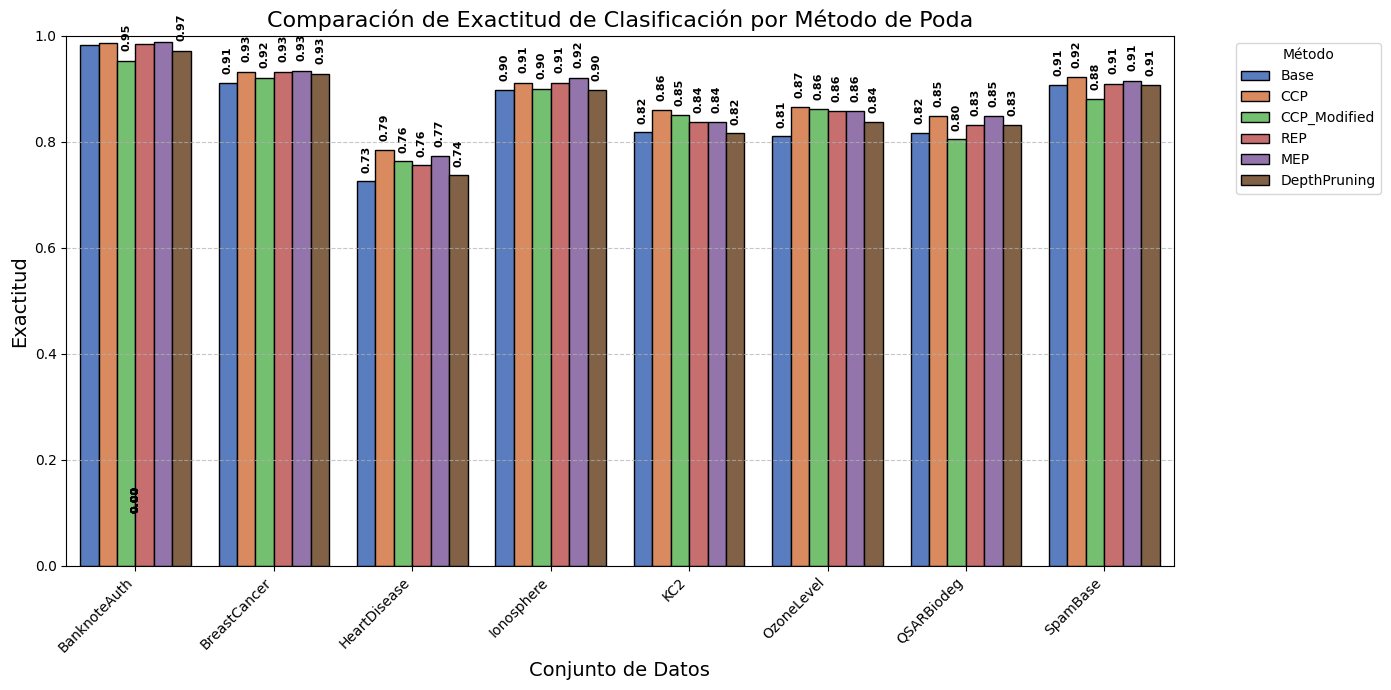

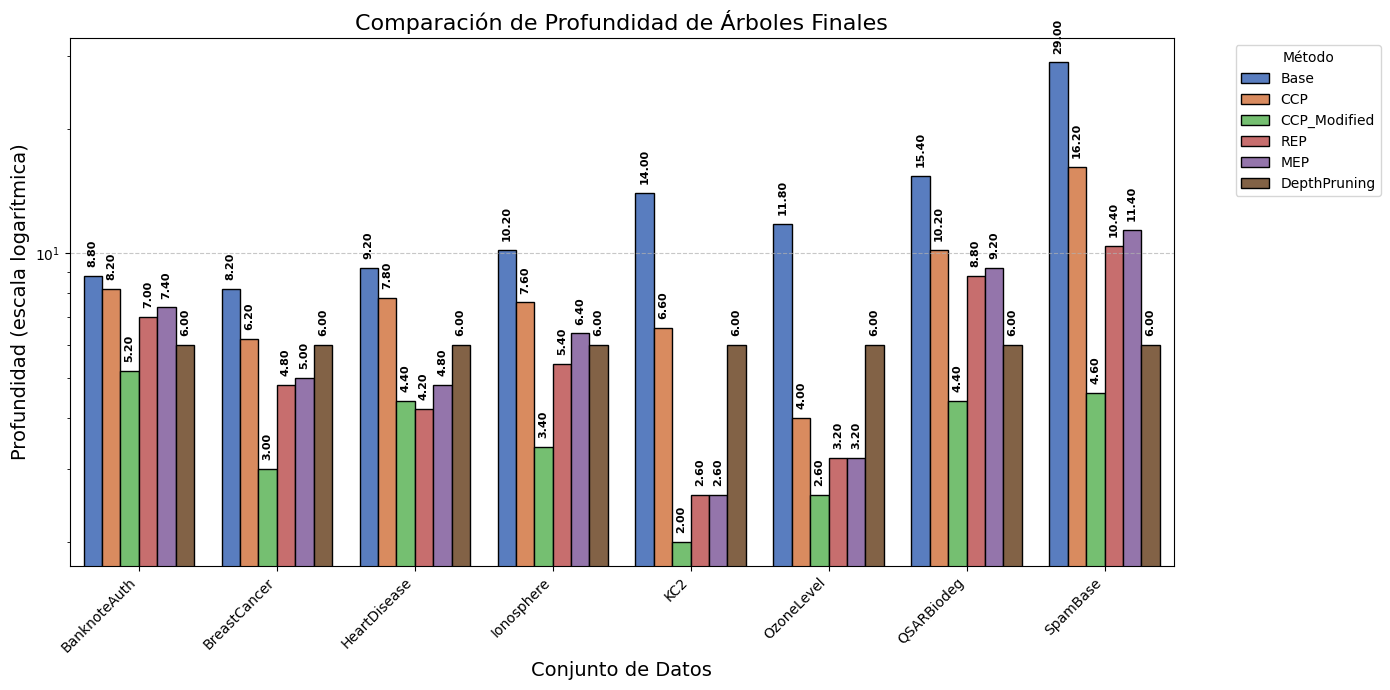

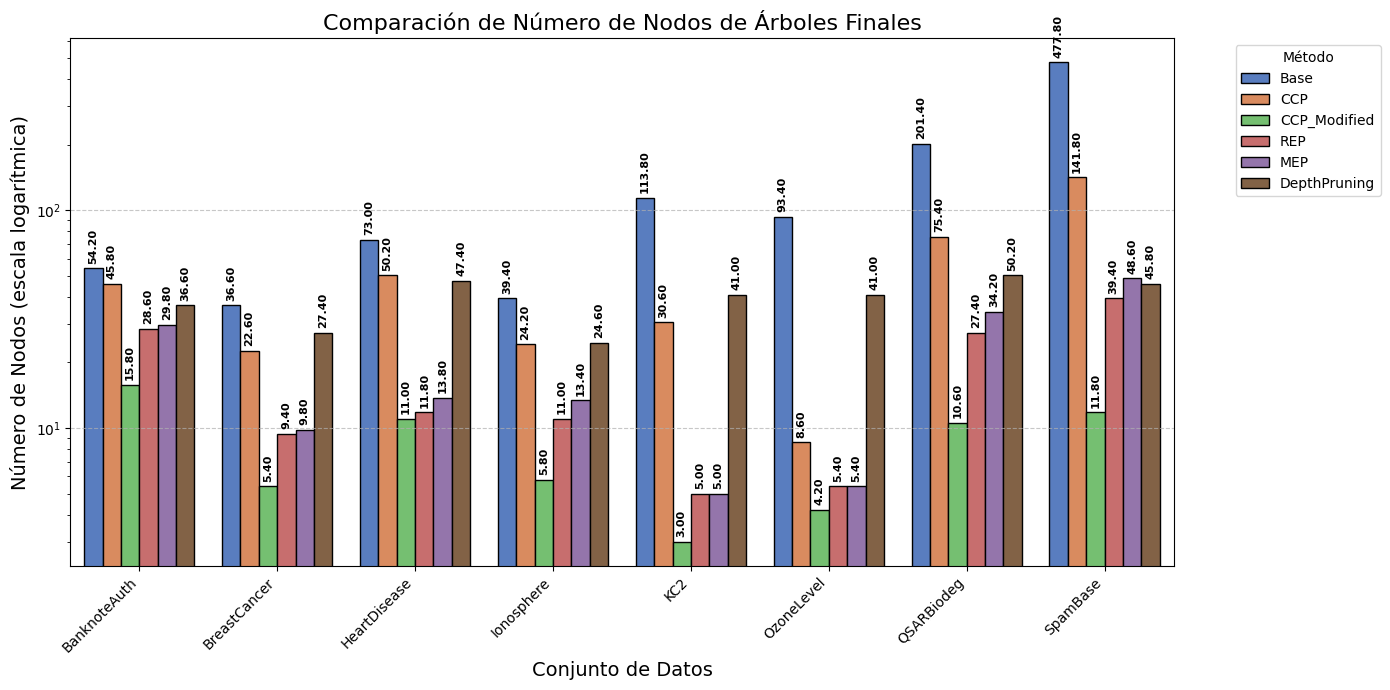

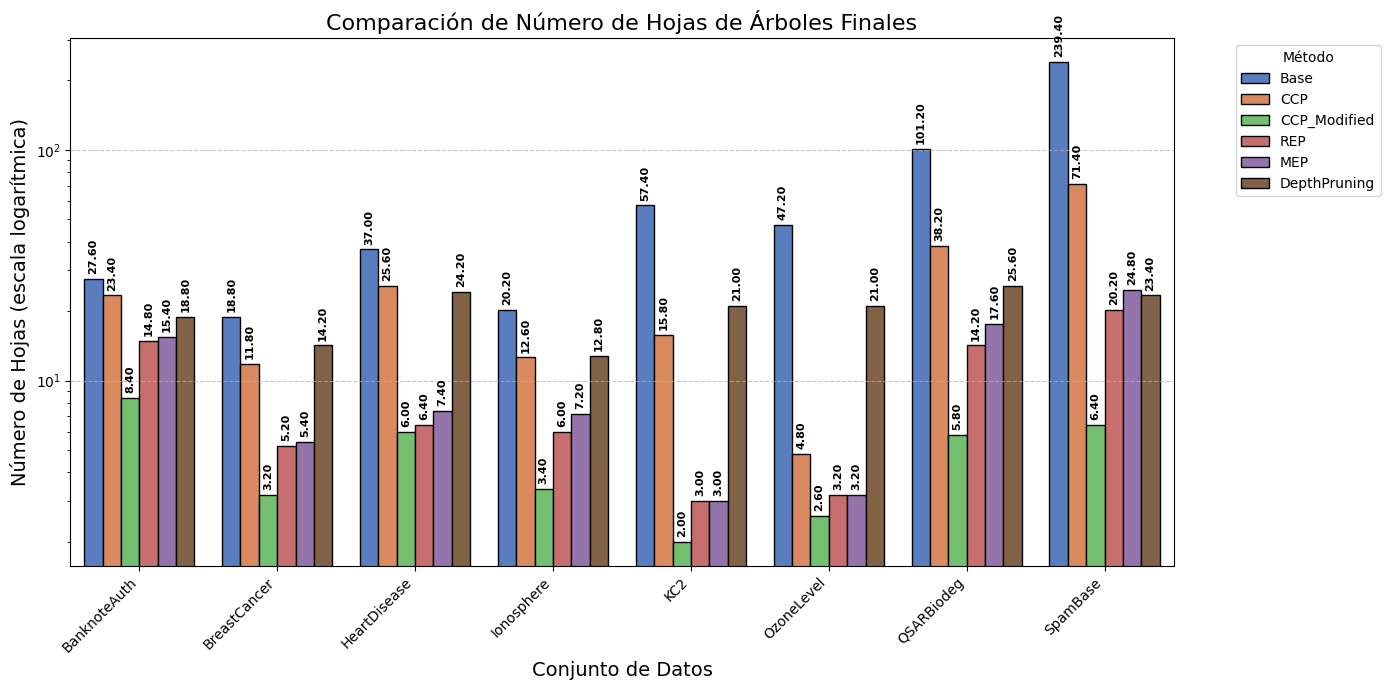

In [ ]:
# ======================= RESULTADOS ===========================
results_df = pd.DataFrame(results, columns=[
    "Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy",
    "Depth", "Nodes", "Leaves", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features"
])
print(results_df)

# ========== RESULTADOS ADICIONALES ==========
metrics_df = results_df[["Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features"]]
accuracy_df = results_df[["Dataset", "Method", "Accuracy"]].rename(columns={"Accuracy": "Test Accuracy"})
details_df = results_df[["Dataset", "Method", "Depth", "Nodes", "Leaves"]]


print("\nMetricas de Prueba por Método:")
print(metrics_df.pivot(index="Dataset", columns="Method"))

print("\nDetalles de Árboles:")
print(details_df)

#========================== ANOVA ===================================

anova_result_acc = f_oneway(*[group['Accuracy'].values for name, group in metrics_df.groupby('Method')])
anova_result_f1 = f_oneway(*[group['F1_Score'].values for name, group in metrics_df.groupby('Method')])
anova_result_bal = f_oneway(*[group['Balanced_Accuracy'].values for name, group in metrics_df.groupby('Method')])

anova_result_leav = f_oneway(*[group['Depth'].values for name, group in details_df.groupby('Method')])
anova_result_depth = f_oneway(*[group['Nodes'].values for name, group in details_df.groupby('Method')])
anova_result_nodes = f_oneway(*[group['Leaves'].values for name, group in details_df.groupby('Method')])

anova_featu_nodes = f_oneway(*[group['n_Features'].values for name, group in metrics_df.groupby('Method')])
print(anova_featu_nodes)

# ========================== CSV FINAL UNIFICADO CON Δacc ==========================

# Obtener accuracy base por dataset
base_accuracies = results_df[results_df["Method"] == "Base"][["Dataset", "Accuracy"]].set_index("Dataset")

# Añadir columna Δacc
results_df["△acc"] = results_df.apply(
    lambda row: row["Accuracy"] - base_accuracies.loc[row["Dataset"], "Accuracy"]
    if row["Method"] != "Base" else 0.0,
    axis=1
)

# Reordenar y renombrar columnas
final_df = results_df[["Dataset", "Method", "Accuracy", "△acc", "F1_Score", "Balanced_Accuracy", "Leaves", "Nodes", "Depth", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features"]]

# Guardar CSV final
final_df.to_csv("FINAL_RESULTADOS.csv", index=False)

# Mostrar resumen final
print("\nCSV Final Consolidado:")
print(final_df)


# Descargar en Colab si aplica
try:
    from google.colab import files
    files.download("FINAL_RESULTADOS.csv")
except:
    print("Descarga automática no disponible (no estás en Colab).")


#==============GRAFICAS INTERPRETABLES==================


# Función para anotar las barras
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, separadas adecuadamente."""
    for p in ax.patches:
        height = p.get_height()
        # Definir un pequeño desplazamiento proporcional
        offset = height * 0.020 if height > 0 else 0.1
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width() / 2., height + offset),
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 1: Exactitud por Método (sin escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=accuracy_df, x="Dataset", y="Test Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Exactitud de Clasificación por Método de Poda", fontsize=16)
plt.ylabel("Exactitud", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

#CARACTERÍSTICAS

# Función para anotar las barras correctamente, incluso las de valor 0
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, manejando valores cero correctamente."""
    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            # Para barras de altura 0, colocarlo en un mínimo visible
            ax.annotate("0",
                        (p.get_x() + p.get_width() / 2., 0.2),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)
        else:
            offset = height * 0.05
            ax.annotate(fmt.format(height),
                        (p.get_x() + p.get_width() / 2., height + offset),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 2: Profundidad de Árboles (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Depth", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Profundidad de Árboles Finales", fontsize=16)
plt.ylabel("Profundidad (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 3: Cantidad de Nodos (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Nodes", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Nodos de Árboles Finales", fontsize=16)
plt.ylabel("Número de Nodos (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 4: Cantidad de Hojas (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Leaves", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Hojas de Árboles Finales", fontsize=16)
plt.ylabel("Número de Hojas (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()


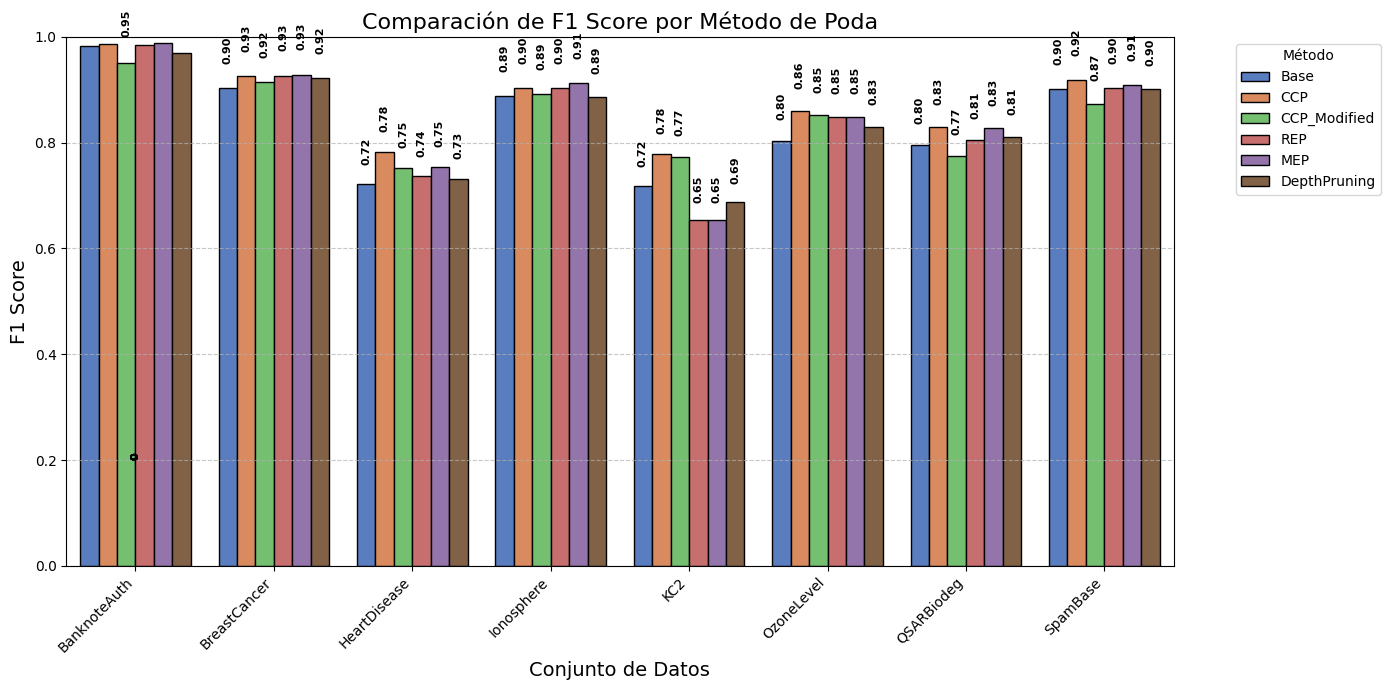

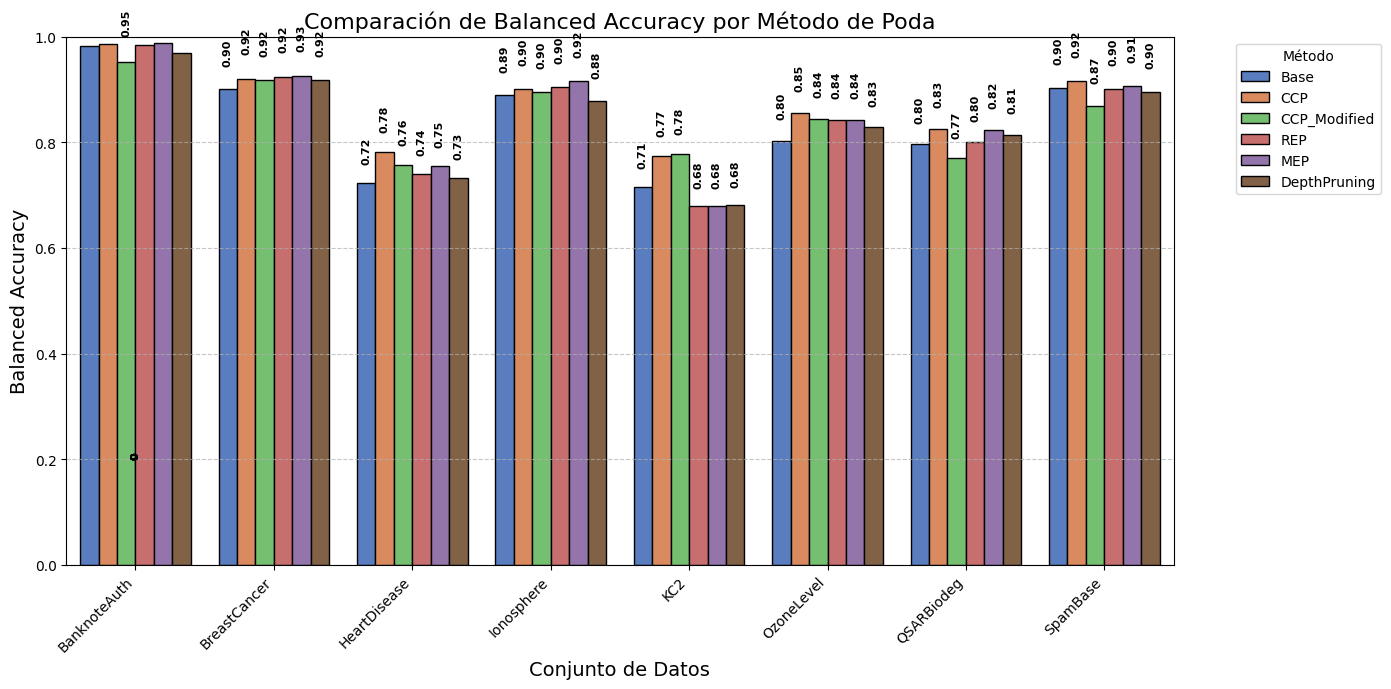

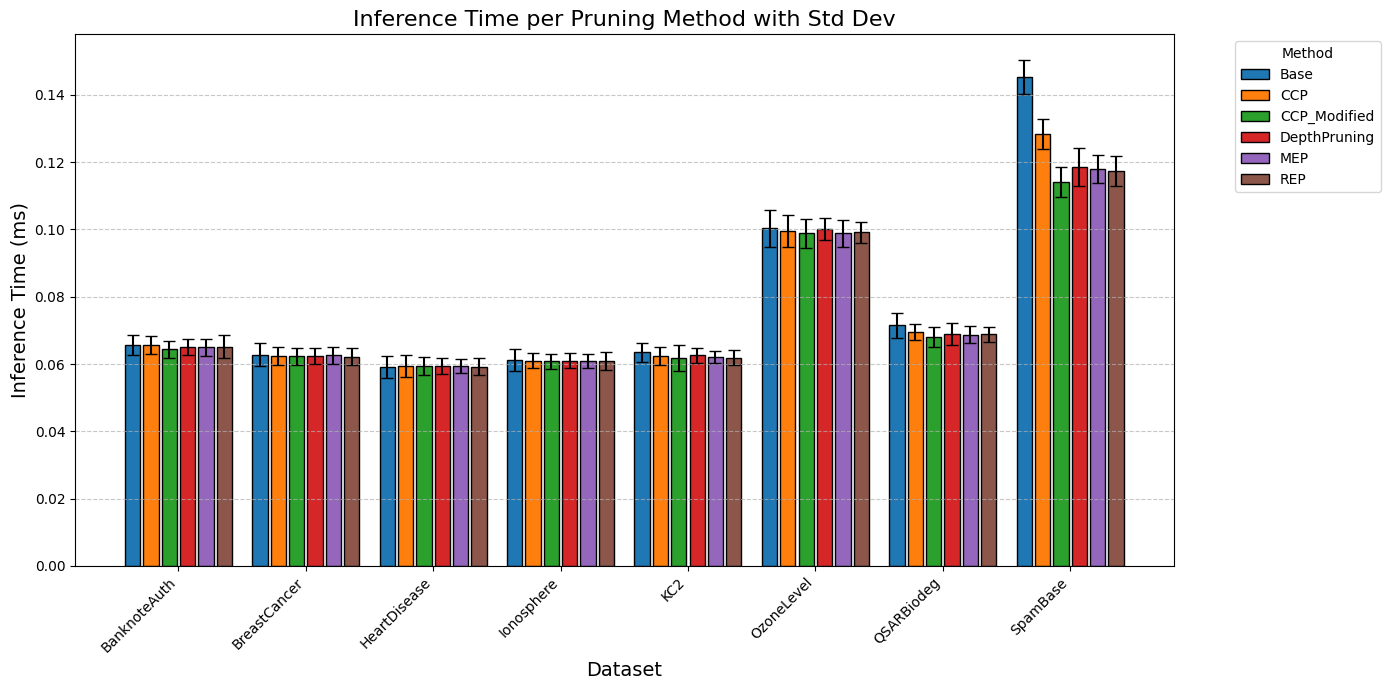

In [ ]:
# Gráfica de barras para F1 Score
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="F1_Score", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de F1 Score por Método de Poda", fontsize=16)
plt.ylabel("F1 Score", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# Gráfica de barras para Balanced Accuracy
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Balanced_Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Balanced Accuracy por Método de Poda", fontsize=16)
plt.ylabel("Balanced Accuracy", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()




# Compute average and std per group
grouped = metrics_df.groupby(["Dataset", "Method"], as_index=False).mean()

# Create the bar plot with error bars
plt.figure(figsize=(14, 7))

# Get unique methods and datasets
methods = grouped["Method"].unique()
datasets = grouped["Dataset"].unique()

# Create position indices for grouped bars
x = np.arange(len(datasets))
width = 0.12  # width of each bar
offsets = np.linspace(-width*len(methods)/2, width*len(methods)/2, len(methods))

for i, method in enumerate(methods):
    subset = grouped[grouped["Method"] == method]
    y = subset["Inference_Time_ms"].values
    yerr = subset["Inference_Time_Std_ms"].values
    plt.bar(x + offsets[i], y, width, label=method, yerr=yerr, capsize=4, edgecolor="black")

plt.xticks(x, datasets, rotation=45, ha="right")
plt.title("Inference Time per Pruning Method with Std Dev", fontsize=16)
plt.xlabel("Dataset", fontsize=14)
plt.ylabel("Inference Time (ms)", fontsize=14)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.ylim(bottom=0)
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


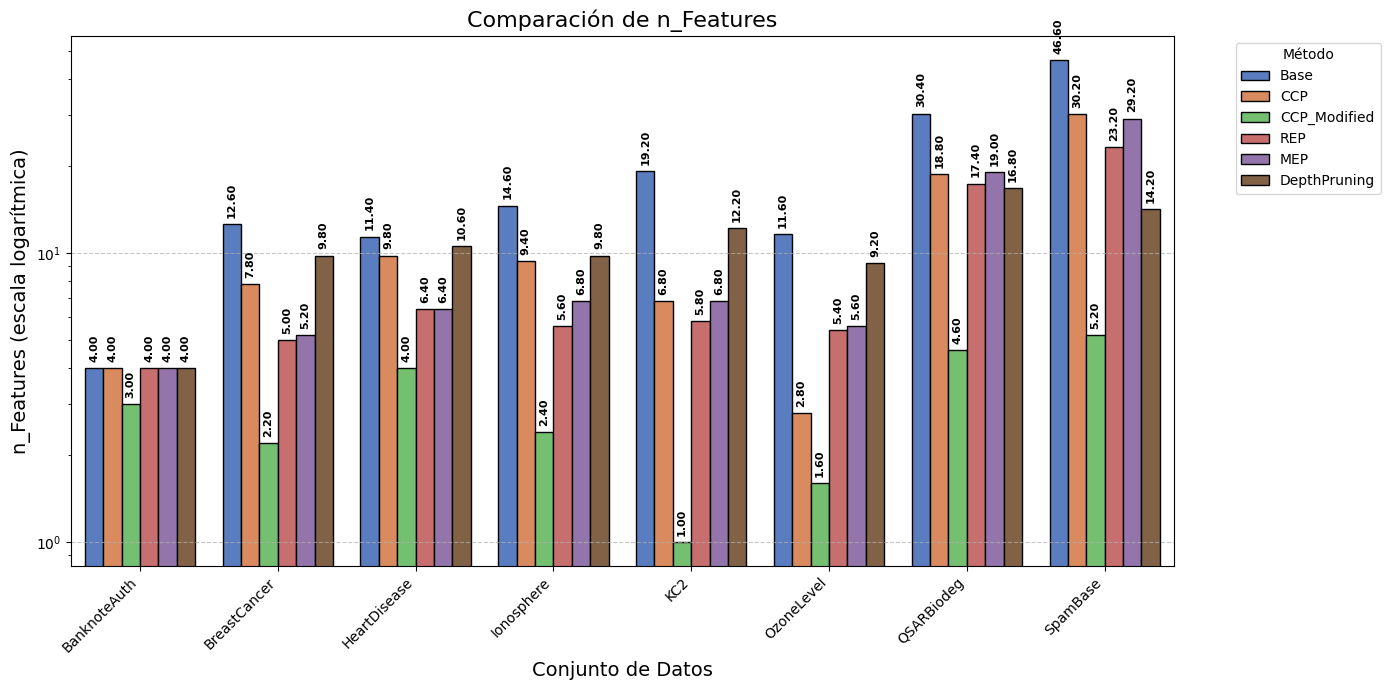

In [ ]:
# === Gráfica 5: n_Features ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="n_Features", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de n_Features", fontsize=16)
plt.ylabel("n_Features (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()